In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer  # Explicitly enable experimental features
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer, QuantileTransformer,
    OneHotEncoder, OrdinalEncoder, PolynomialFeatures, FunctionTransformer, KBinsDiscretizer
)
from sklearn.feature_extraction import FeatureHasher
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, SelectFromModel
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans


sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../Data/Train.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1000, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,C,Flight,2,5,306,6,high,M,45,3838,1
1,2,F,Ship,7,2,114,3,high,M,35,2710,1
2,3,B,Ship,7,2,215,7,medium,F,44,4152,0
3,4,A,Road,5,3,126,5,medium,M,54,2245,0
4,5,F,Ship,3,5,113,3,medium,M,43,1806,1


In [3]:
np.random.seed(101)

rows = 1200

synthetic_df = pd.DataFrame({

    "Warehouse_block": np.random.choice(list("ABCDF"), rows),

    "Mode_of_Shipment": np.random.choice(
        ["Flight", "Ship", "Road", None], rows, p=[0.35,0.35,0.2,0.1]
    ),

    "Customer_care_calls": np.random.randint(2,8,rows),

    "Customer_rating": np.random.randint(1,6,rows),

    "Cost_of_the_Product": np.random.gamma(3,70,rows),

    "Prior_purchases": np.random.randint(1,10,rows),

    "Product_importance": np.random.choice(
        ["low","medium","high"], rows, p=[0.5,0.3,0.2]
    ),

    "Gender": np.random.choice(["M","F"], rows),

    "Discount_offered": np.random.lognormal(2.2,0.6,rows).astype(int),

    "Weight_in_gms": np.random.normal(3800,1100,rows),

    "Reached.on.Time_Y.N": np.random.randint(0,2,rows)
})

print("Synthetic Dataset Created ✔")
synthetic_df.head()

Synthetic Dataset Created ✔


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Ship,6,4,154.740329,5,low,F,3,3969.295716,1
1,B,Flight,3,3,307.390877,6,low,F,8,3154.652665,1
2,D,Road,6,5,309.646391,1,low,F,22,2764.908255,1
3,B,Ship,6,4,136.076026,5,medium,M,10,2458.620082,1
4,A,Road,5,3,464.741377,6,low,M,3,3467.106643,1


In [4]:
target = "Reached.on.Time_Y.N"

features = df.drop(columns=[target], errors="ignore")
labels = df[target]

print("Features:", features.shape)
print("Labels:", labels.shape)

Features: (1000, 11)
Labels: (1000,)


In [5]:
num_cols = features.select_dtypes(include=np.number).columns.tolist()
cat_cols = features.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']
Categorical: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']


In [6]:
numeric_pipe = Pipeline([
    ("knn_impute", KNNImputer(n_neighbors=3)),
    ("robust_scale", RobustScaler())
])

In [7]:
categorical_pipe = Pipeline([
    ("cat_impute", SimpleImputer(strategy="most_frequent")),
    ("encoding", OneHotEncoder(handle_unknown="ignore"))
])

In [8]:
preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

preprocess

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,3
,weights,'uniform'


In [9]:
X_processed = preprocess.fit_transform(features)

print("Processed Shape:", X_processed.shape)

Processed Shape: (1000, 20)


In [10]:
iso_model = IsolationForest(contamination=0.04, random_state=42)

features["outlier_flag"] = iso_model.fit_predict(features[num_cols])

print(features["outlier_flag"].value_counts())

outlier_flag
 1    960
-1     40
Name: count, dtype: int64


In [11]:
iso_data = synthetic_df[["Weight_in_gms","Cost_of_the_Product","Discount_offered"]].fillna(0)

iso_model = IsolationForest(contamination=0.05, random_state=101)

flags = iso_model.fit_predict(iso_data)

synthetic_clean = synthetic_df[flags == 1]

print("Synthetic Outliers Removed:", len(synthetic_df)-len(synthetic_clean))

Synthetic Outliers Removed: 60


C:\Users\rishi\AppData\Local\Temp\ipykernel_1780\1975563128.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  synthetic_clean["Cost_normalized"] = qt.fit_transform(


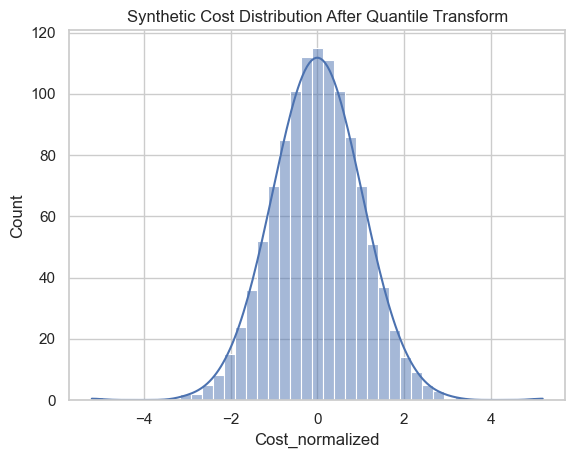

In [12]:
qt = QuantileTransformer(output_distribution="normal")

synthetic_clean["Cost_normalized"] = qt.fit_transform(
    synthetic_clean[["Cost_of_the_Product"]]
)

sns.histplot(synthetic_clean["Cost_normalized"], kde=True)
plt.title("Synthetic Cost Distribution After Quantile Transform")
plt.show()

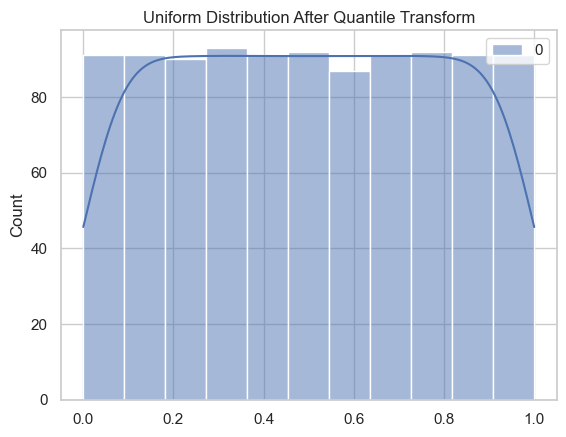

In [13]:
qt = QuantileTransformer(output_distribution="uniform")

qt_values = qt.fit_transform(df[["Cost_of_the_Product"]])

sns.histplot(qt_values, kde=True)
plt.title("Uniform Distribution After Quantile Transform")
plt.show()

In [14]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_processed)

print("PCA Shape:", pca_data.shape)

PCA Shape: (1000, 2)


In [15]:
mice_imputer = IterativeImputer(max_iter=10, random_state=42)

mice_data = mice_imputer.fit_transform(
    df[['Cost_of_the_Product','Weight_in_gms','Discount_offered']]
)

print("MICE Output Shape:", mice_data.shape)

MICE Output Shape: (1000, 3)
